## 0. Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

# Load dataset
df = pd.read_csv('Reviews.csv')

# Reproduce Sentiment column (same logic as team)
def get_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(get_sentiment)

# Sample 20000 rows (same seed as team)
df = df.sample(20000, random_state=42).reset_index(drop=True)

# Text Cleaning
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['Cleaned_Text'] = df['Text'].apply(clean_text)
df['review_length'] = df['Cleaned_Text'].apply(lambda x: len(x.split()))

print('Dataset shape:', df.shape)
df.head(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset shape: (20000, 13)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,Cleaned_Text,review_length
0,15114,B0013E21V8,AJAEA74EF21NF,motheroflittle,16,18,5,1223683200,Highland Sugarworks Syrup is the best,This syrup is so good. I do not usually like m...,Positive,syrup good usually like maple syrup one delici...,37
1,64943,B005MWAM72,A3GMVCTJTHYG1F,Mom22boys,0,0,5,1342656000,Delicious and easy to prepare!,My son loves Maple Brown Sugar Cream of Wheat ...,Positive,son loves maple brown sugar cream wheat offere...,57
2,26073,B0058AMY74,AJQD2WWJYOYFQ,bubbles,0,0,4,1186617600,"Tangy, spicy, and sweet- oh my!",Kettle Chips Spicy Thai potato chips have the ...,Positive,kettle chips spicy thai potato chips perfect a...,77


---
## 1. EDA — Graphs & Visualizations

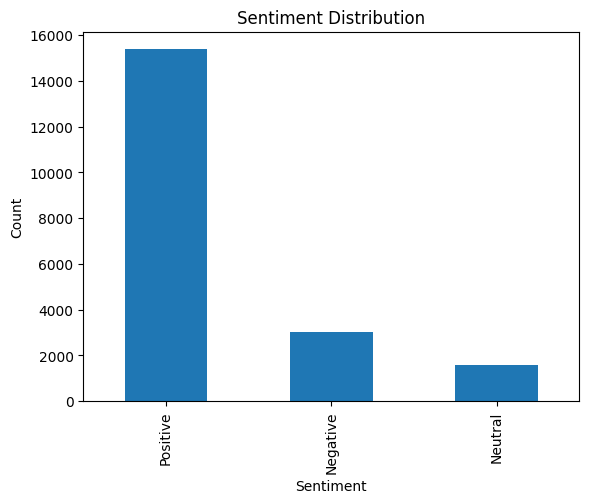

In [4]:
# EDA
# -----------------------------------
import matplotlib.pyplot as plt

# 1. Sentiment Distribution
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


### 1.3 Review Length Distribution by Sentiment

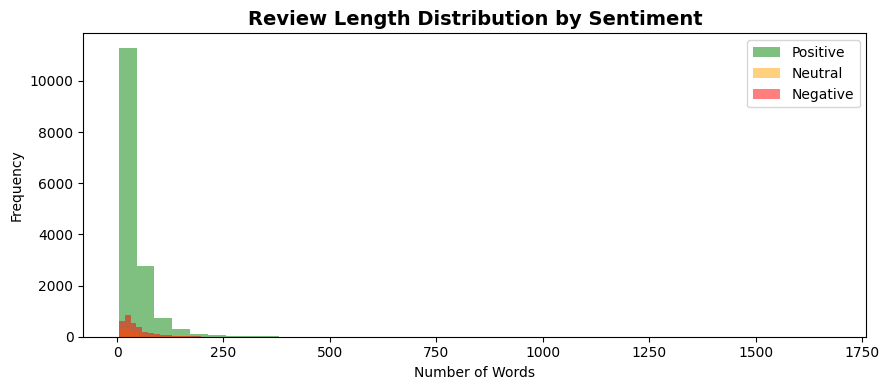

             count  mean   std  min   25%   50%   75%     max
Sentiment                                                    
Negative    3034.0  44.9  41.8  4.0  20.0  33.0  55.0   559.0
Neutral     1577.0  49.8  45.6  6.0  20.0  35.0  64.0   472.0
Positive   15389.0  40.0  43.3  4.0  16.0  27.0  47.0  1677.0


In [6]:
plt.figure(figsize=(9, 4))
for sentiment, color in [('Positive', 'green'), ('Neutral', 'orange'), ('Negative', 'red')]:
    subset = df[df['Sentiment'] == sentiment]['review_length']
    plt.hist(subset, bins=40, alpha=0.5, label=sentiment, color=color)

plt.title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby('Sentiment')['review_length'].describe().round(1))

### 1.4 Top 20 Most Frequent Words (Overall)

In [ ]:
all_words = ' '.join(df['Cleaned_Text']).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='mediumpurple', edgecolor='black')
plt.title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

### 1.5 Sentiment Proportion — Pie Chart

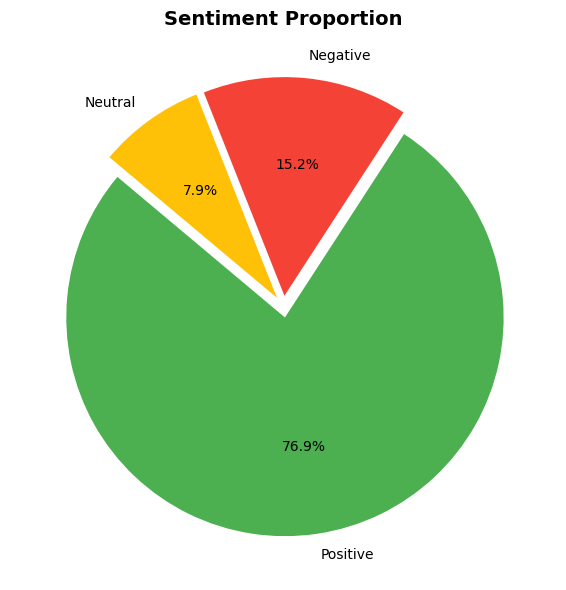

In [7]:
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=['#4CAF50', '#F44336', '#FFC107'],
    autopct='%1.1f%%',
    startangle=140,
    explode=[0.05, 0.05, 0.05]
)
plt.title('Sentiment Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Category Creation from Text

We create product categories by looking for **keyword patterns** in the review text.  
This is a rule-based text categorization — no model needed.

In [8]:
# Define keyword rules for categories
category_keywords = {
    'Food & Snacks':   ['food', 'snack', 'chip', 'cookie', 'cracker', 'candy', 'chocolate',
                        'cereal', 'granola', 'pretzel', 'popcorn', 'nut', 'peanut', 'almond'],
    'Beverages':       ['coffee', 'tea', 'drink', 'juice', 'water', 'soda', 'beverage',
                        'lemonade', 'energy', 'wine', 'beer', 'brew', 'espresso'],
    'Health & Organic':['organic', 'natural', 'healthy', 'vitamin', 'supplement', 'protein',
                        'gluten', 'vegan', 'keto', 'diet', 'fiber', 'probiotic', 'herbal'],
    'Pet Food':        ['dog', 'cat', 'pet', 'puppy', 'kitten', 'treat', 'kibble', 'paw',
                        'animal', 'fur', 'vet'],
    'Condiments & Spices': ['sauce', 'spice', 'seasoning', 'salt', 'pepper', 'vinegar',
                            'ketchup', 'mustard', 'mayo', 'dressing', 'herb', 'garlic'],
    'Dairy & Alternatives': ['milk', 'cheese', 'butter', 'cream', 'yogurt', 'dairy',
                             'almond milk', 'soy milk', 'lactose'],
    'Pasta & Grains':  ['pasta', 'rice', 'wheat', 'bread', 'flour', 'grain', 'oat',
                        'noodle', 'quinoa', 'barley', 'corn', 'maize'],
}

def assign_category(text):
    text_lower = str(text).lower()
    for category, keywords in category_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                return category
    return 'Other'

df['Category'] = df['Text'].apply(assign_category)

print('Category distribution:')
print(df['Category'].value_counts())

Category distribution:
Category
Food & Snacks           8175
Beverages               4928
Other                   2706
Pet Food                1376
Health & Organic         943
Pasta & Grains           880
Condiments & Spices      747
Dairy & Alternatives     245
Name: count, dtype: int64


### 2.1 Category Distribution — Bar Chart

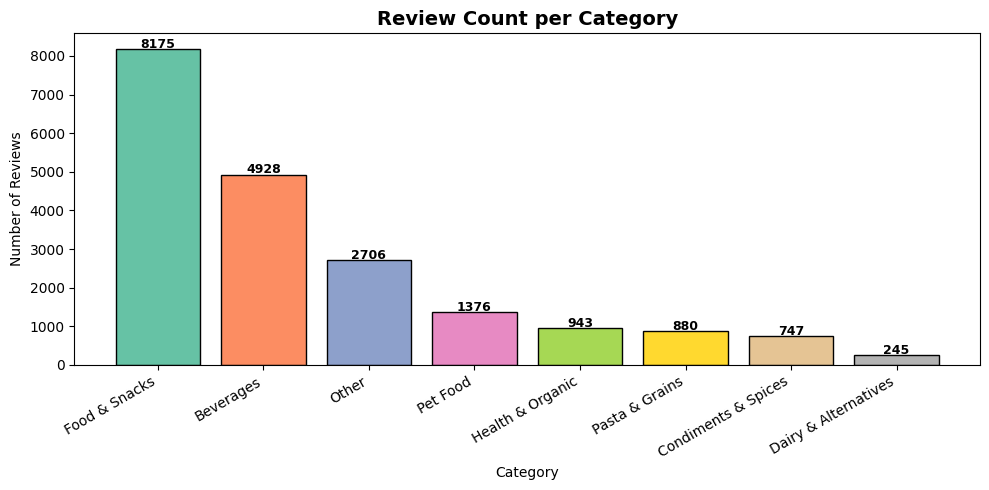

In [9]:
cat_counts = df['Category'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(cat_counts.index, cat_counts.values,
               color=sns.color_palette('Set2', len(cat_counts)),
               edgecolor='black')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 30,
             str(int(bar.get_height())),
             ha='center', fontsize=9, fontweight='bold')

plt.title('Review Count per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Category-wise Analysis

### 3.1 Sentiment Distribution per Category (Stacked Bar)

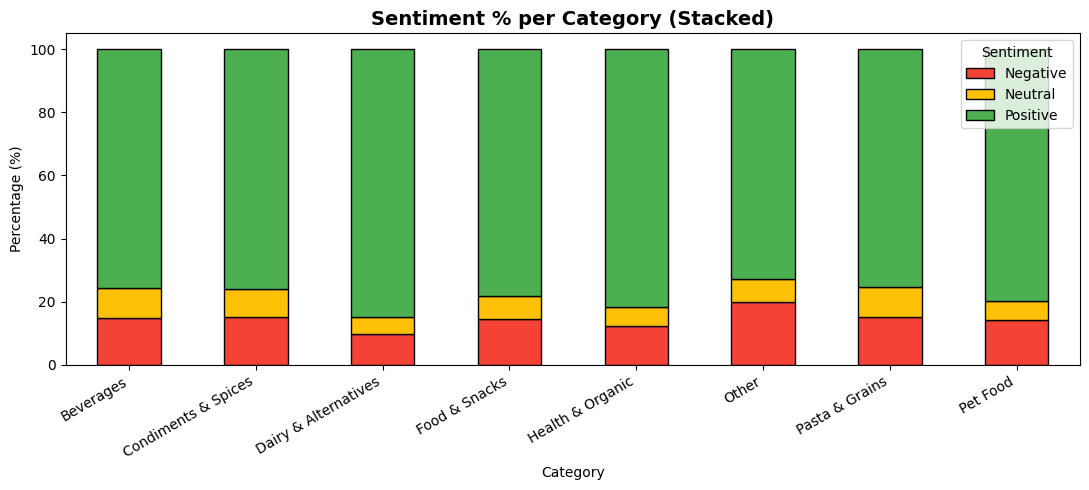

In [10]:
cat_sentiment = df.groupby(['Category', 'Sentiment']).size().unstack(fill_value=0)

# Normalize to proportions
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

cat_sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 5),
    color=['#F44336', '#FFC107', '#4CAF50'],
    edgecolor='black'
)

plt.title('Sentiment % per Category (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()

### 3.2 Average Star Score per Category

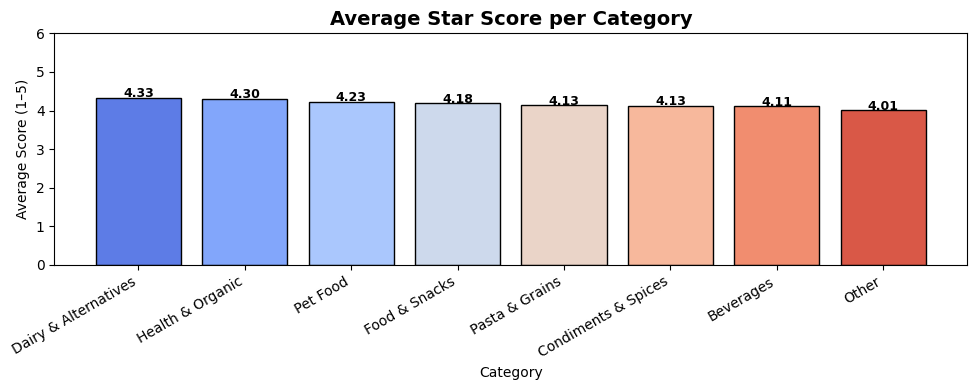

In [11]:
avg_score = df.groupby('Category')['Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(avg_score.index, avg_score.values,
               color=sns.color_palette('coolwarm', len(avg_score)),
               edgecolor='black')

for bar, val in zip(bars, avg_score.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{val:.2f}',
             ha='center', fontsize=9, fontweight='bold')

plt.title('Average Star Score per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Average Score (1–5)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

### 3.3 Average Review Length per Category

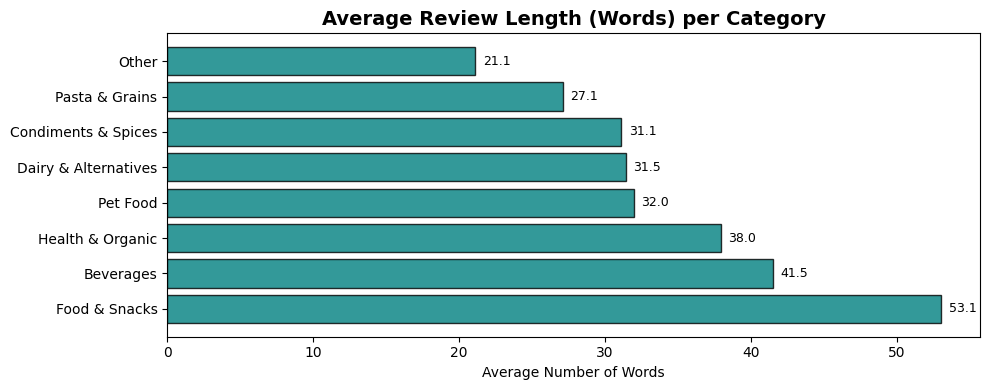

In [12]:
avg_len = df.groupby('Category')['review_length'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.barh(avg_len.index, avg_len.values,
         color='teal', edgecolor='black', alpha=0.8)

for i, val in enumerate(avg_len.values):
    plt.text(val + 0.5, i, f'{val:.1f}', va='center', fontsize=9)

plt.title('Average Review Length (Words) per Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Number of Words')
plt.tight_layout()
plt.show()

### 3.4 Top 10 Words per Category

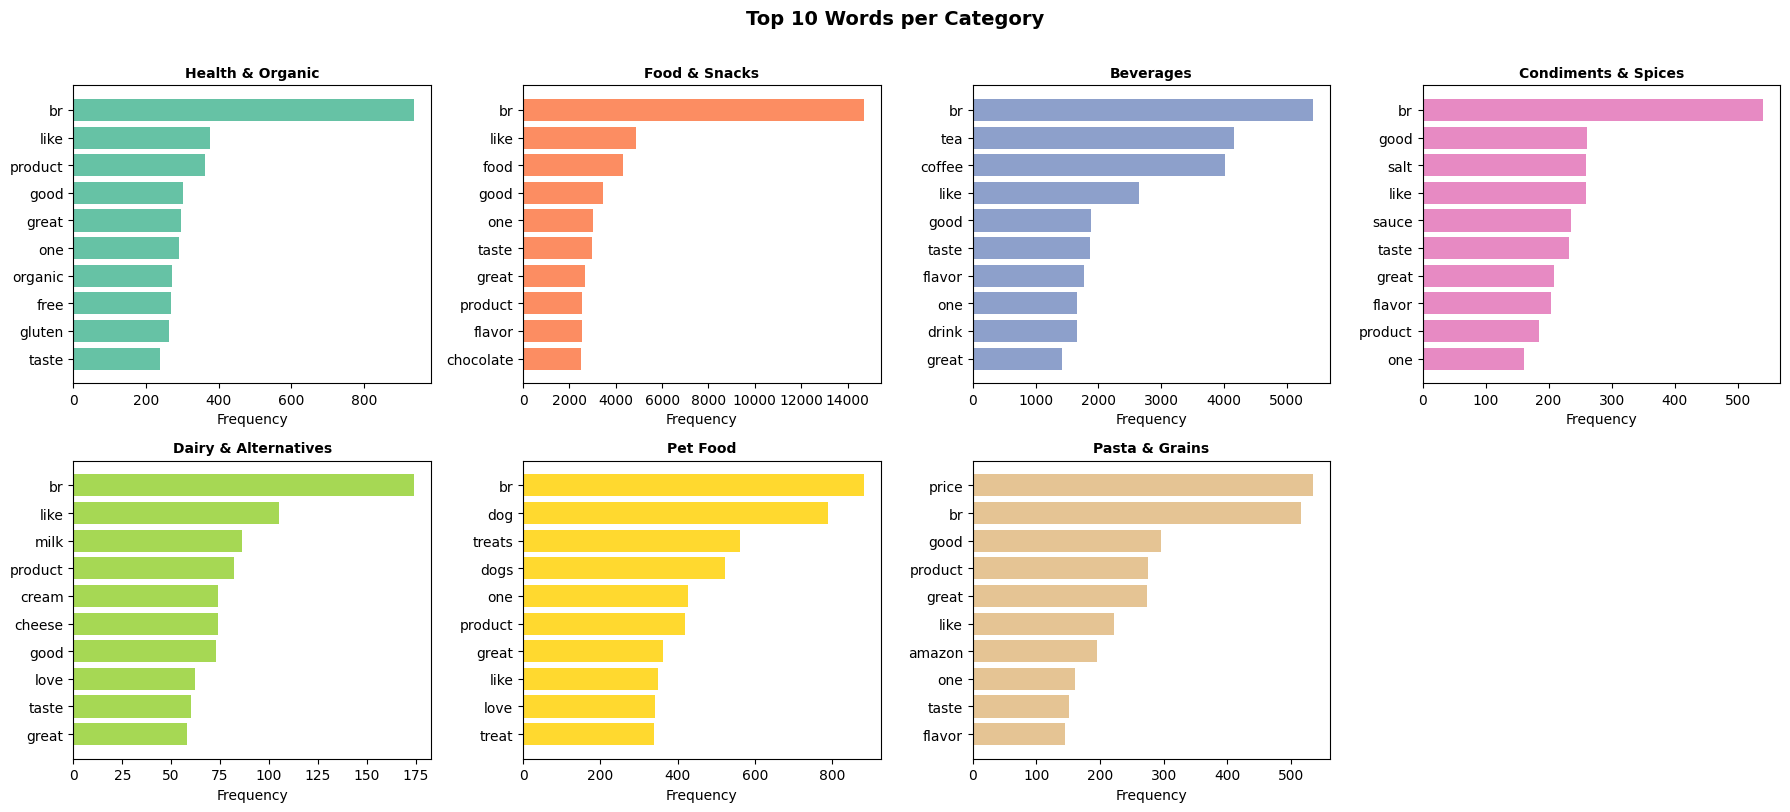

In [13]:
categories_to_plot = [c for c in df['Category'].unique() if c != 'Other']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, cat in enumerate(categories_to_plot):
    subset = df[df['Category'] == cat]['Cleaned_Text']
    words = ' '.join(subset).split()
    top10 = Counter(words).most_common(10)
    w, c = zip(*top10) if top10 else ([], [])
    axes[idx].barh(list(w)[::-1], list(c)[::-1],
                   color=sns.color_palette('Set2')[idx % 8])
    axes[idx].set_title(cat, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Frequency')

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Words per Category', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Category-wise Summary Table

In [14]:
summary = df.groupby('Category').agg(
    Total_Reviews=('Text', 'count'),
    Avg_Score=('Score', 'mean'),
    Avg_Length=('review_length', 'mean'),
    Positive_Count=('Sentiment', lambda x: (x == 'Positive').sum()),
    Neutral_Count=('Sentiment', lambda x: (x == 'Neutral').sum()),
    Negative_Count=('Sentiment', lambda x: (x == 'Negative').sum()),
).round(2)

summary['Positive_%'] = (summary['Positive_Count'] / summary['Total_Reviews'] * 100).round(1)
summary['Negative_%'] = (summary['Negative_Count'] / summary['Total_Reviews'] * 100).round(1)

summary.sort_values('Total_Reviews', ascending=False)

,Total_Reviews,Avg_Score,Avg_Length,Positive_Count,Neutral_Count,Negative_Count,Positive_%,Negative_%
Category,,,,,,,,
Food & Snacks,8175,4.18,53.07,6391,602,1182,78.2,14.5
Beverages,4928,4.11,41.52,3721,472,735,75.5,14.9
Other,2706,4.01,21.14,1973,198,535,72.9,19.8
Pet Food,1376,4.23,31.98,1096,84,196,79.7,14.2
Health & Organic,943,4.30,37.98,769,58,116,81.5,12.3
Pasta & Grains,880,4.13,27.14,664,83,133,75.5,15.1
Condiments & Spices,747,4.13,31.14,567,67,113,75.9,15.1
Dairy & Alternatives,245,4.33,31.46,208,13,24,84.9,9.8
